# Exclusive-fate replacement ablation

Compare three **single-source-cell** interventions with the same unchanged recipient, graph and supplied size:

1. **Zero → unassigned:** the previous marker ablation, which is identity replacement in an exclusive vector.
2. **Context-matched replacement, fixed weights:** average discrete replacement predictions with weights fitted at the source organoid's **observed N**, held fixed during the sweep.
3. **Context-matched replacement, N-dependent weights:** recompute the reference mixture at each **supplied N**.

All seven measured fates and **Unassigned** are included as recipient and source identities. An unassigned source has a zero old-ablation effect by construction; replacing it with an assigned identity can have an effect. Static means inference at each organoid's observed size, not removal of size conditioning. At observed N, the two replacement variants coincide exactly.

This is a fresh analysis across all identity combinations, without selecting a particular marker pair, size minimum, or biological hypothesis. Existing exclusive FiLM checkpoints are reused; **no training occurs**.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Open this notebook inside the GraphNN project.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analysis.replacement_ablation import (
    MatchConfig, run_replacement_analysis, load_comparison,
)
from src.plotting.replacement_ablation import (
    plot_pair_grid, plot_support, plot_reference_weights,
)

## Settings to inspect

Matching uses full-graph source context, even when prediction is evaluated on an exact two-hop recipient ego. Donors come only from the model's training fold. A donor must have a different identity and have the recipient identity in its exact hop-1 or hop-2 ring.

Within that pool, nearest-neighbor matching uses log(1 + degree), eight neighboring identity fractions, and log N. One distance unit corresponds to a degree-plus-one ratio of two, a 25 percentage-point change in one fraction, or a size ratio of two. The candidate's own identity is excluded from the descriptor. Hard calipers and minimum donor counts reject weakly supported matches. No curvature, predictions, crypt labels, geometry, or timepoint labels are used for matching.

Each selected donor organoid has equal total weight. Low-support replacement identities are removed, and the remaining probabilities are renormalized. The original source identity is always excluded; this estimates **replacement by a different identity**, not unconditional identity imputation. Unassigned is an ordinary donor identity. These defaults are adjustable descriptive matching choices, not a calibrated model of biological conversions.

In [2]:
RUN_DIR = ROOT / 'results_experiments/size_conditioned_exclusive/20260914_ordered_exclusive_film_depth2/exclusive'
OUTPUT_DIR = ROOT / 'results_experiments/replacement_ablation/exclusive_film_v1'

# None selects all saved folds / all model seeds, respectively.
FOLDS = None
MODEL_SEEDS = None
SWEEP_COUNTS = json.loads((RUN_DIR / 'sweep_grid.json').read_text())
HOPS = (1, 2)
CENTERS_PER_IDENTITY = 2        # per organoid; every available center identity is sampled
SWEEP_CENTERS_PER_IDENTITY = 1 # fixed subset of those static centers
SAMPLING_SEED = 1701
BATCH_SIZE = 128
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CPU_THREADS = 4

MATCHING = MatchConfig(
    neighbors=256,
    max_size_ratio=2.0,
    max_degree_ratio=2.0,       # applied to degree + 1
    max_composition_l1=1.0,    # total difference across neighboring fate fractions
    min_cells=20,
    min_organoids=5,
    min_identity_cells=5,
    min_identity_organoids=3,
    max_donors_per_organoid=256,
)
BOOTSTRAP_SAMPLES = 500
MIN_PLOT_ORGANOIDS = 5
PLOT_METRIC = 'delta_relative'  # alternatively 'delta_mu' or 'delta_z'

# Inference is resumable; existing matching settings/checkpoints/code must agree.
# Set False to redisplay a completed analysis without running inference.
RUN_INFERENCE = True
print('Device:', DEVICE)
print('Sweep N:', SWEEP_COUNTS)
print('Matching:', MATCHING)
print('Output:', OUTPUT_DIR)

Device: cuda
Sweep N: [165, 201, 244, 297, 361, 439, 535, 650, 791]
Matching: MatchConfig(neighbors=256, max_size_ratio=2.0, max_degree_ratio=2.0, max_composition_l1=1.0, min_cells=20, min_organoids=5, min_identity_cells=5, min_identity_organoids=3, max_donors_per_organoid=256)
Output: /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/replacement_ablation/exclusive_film_v1


## Inference and auditable outputs

Predictions are enumerated for every discrete replacement identity, so there is no Monte Carlo replacement noise. Each replacement prediction is converted back to curvature **before** applying its probability weight. All methods use the same sampled source cells and unchanged recipient identities.

Outputs include donor manifests and training/validation membership, source-case manifests, per-identity donor support, fixed and N-dependent weights, all individual replacement contrasts, and the three averaged contrasts. Unsupported mixtures are missing values; no global-frequency fallback is used. Changing inference settings or code requires a new output directory. Interrupted inference resumes completed fold/seed/N shards.

This cell performs potentially substantial inference over all checkpoints and sizes. It never retrains a model.

In [3]:
torch.set_num_threads(CPU_THREADS)
if RUN_INFERENCE:
    run_replacement_analysis(
        ROOT, RUN_DIR, OUTPUT_DIR,
        counts=SWEEP_COUNTS, folds=FOLDS, seeds=MODEL_SEEDS,
        matcher_config=MATCHING,
        centers_per_identity=CENTERS_PER_IDENTITY,
        sweep_centers_per_identity=SWEEP_CENTERS_PER_IDENTITY,
        hops=HOPS, sampling_seed=SAMPLING_SEED,
        device=DEVICE, batch_size=BATCH_SIZE,
    )
result = load_comparison(OUTPUT_DIR, bootstrap_samples=BOOTSTRAP_SAMPLES)
print('Unique sampled cases:', result['cases'][['fold', 'case_id']].drop_duplicates().shape[0])
print('Identities:', result['config']['markers'])

Loaded 1100 graphs; skipped 0.
=== Target outlier interpolation report ===
Quantiles: [0.005, 0.995]
target 0: range=[-0.201986, 0.236541] | outliers=4778 | replaced=4778 | fallback=42 | rejected_interp=42
Preparing replacement references: fold 0


/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Preparing replacement references: fold 1
Preparing replacement references: fold 2
Preparing replacement references: fold 3
Preparing replacement references: fold 4
Unique sampled cases: 70752
Identities: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin', 'Unassigned']


## Support comes first

For a fair three-method comparison, static plots use cases with replacement support at observed N. Sweep plots use a **constant cohort** supported by both reference schemes at **every** sweep N. The old zero curve is recomputed on exactly that same cohort. This prevents a changing sample from creating a size trend. It also means these curves need not equal earlier notebook averages, which used different sampling and support.

The coverage figure reports the fraction of sampled cases retained. Rare or unsupported combinations remain blank rather than being reported as zero. Inspect coverage before interpreting curves; broad sweeps can leave a small, selected cohort. Fixed weights remain anchored to observed size, so individual fixed alternatives may lose local support at a distant supplied N even when the N-dependent mixture has support.

n_cases  n_supported  fraction
analysis hop                                
observed 1      29775        29730  0.998489
         2      40977        40941  0.999121
sweep    1     140499       140292  0.998527
         2     193464       193185  0.998558

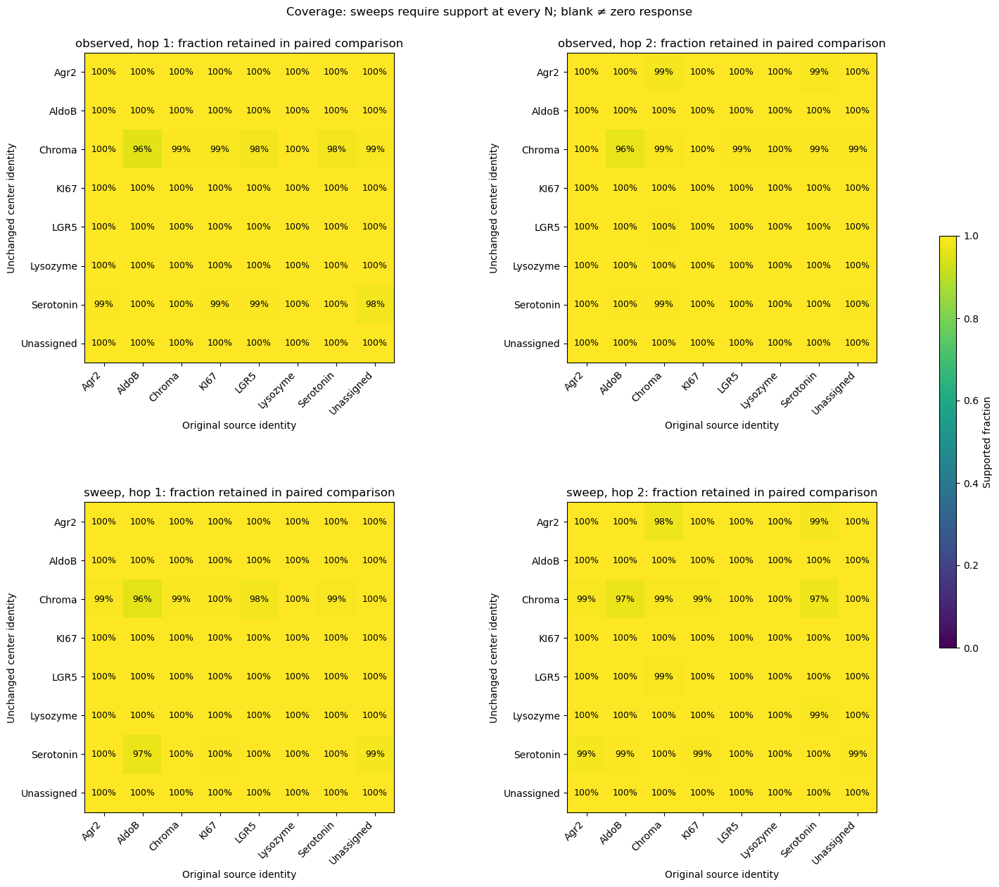

In [4]:
display(result['support'].groupby(['analysis', 'hop'])[['n_cases', 'n_supported']].sum().assign(
    fraction=lambda t: t.n_supported / t.n_cases
))
fig = plot_support(result)
fig.savefig(OUTPUT_DIR / 'figures/01_support.png', dpi=160, bbox_inches='tight')
plt.show()

## Static contrasts at observed N

Rows identify the unchanged **recipient center**; columns identify the original **source cell** being replaced. Each panel compares the three methods within a fixed recipient/source identity and exact hop distance. Static effects are grouped into N bins: <150, 150–249, 250–349, 350–499, 500–799, ≥800; plotted x positions are the median observed counts of supported cases.

The two replacement curves overlap by construction here. A positive effect means the recipient's predicted curvature increases after replacement. The geometrically normalized effect is `ΔK / (4π / A_ref(N))`, with the existing area reference fitted on training organoids only. It is not a percentage change from the recipient's prediction. The per-organoid baseline cancels between intact and replaced predictions.

Cases and model seeds are averaged within organoid before organoids receive equal weight. Bands are pointwise organoid-bootstrap intervals conditional on fitted models and matching references; they do not include retraining or donor-estimation uncertainty. Panels have separate y scales.

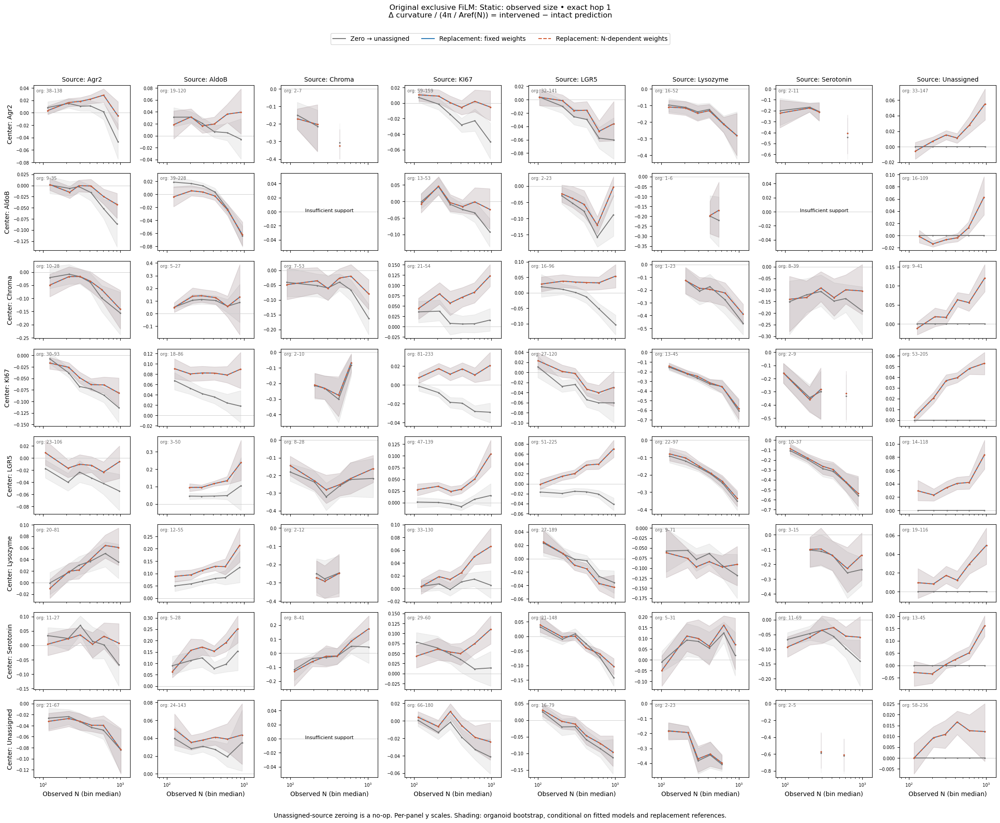

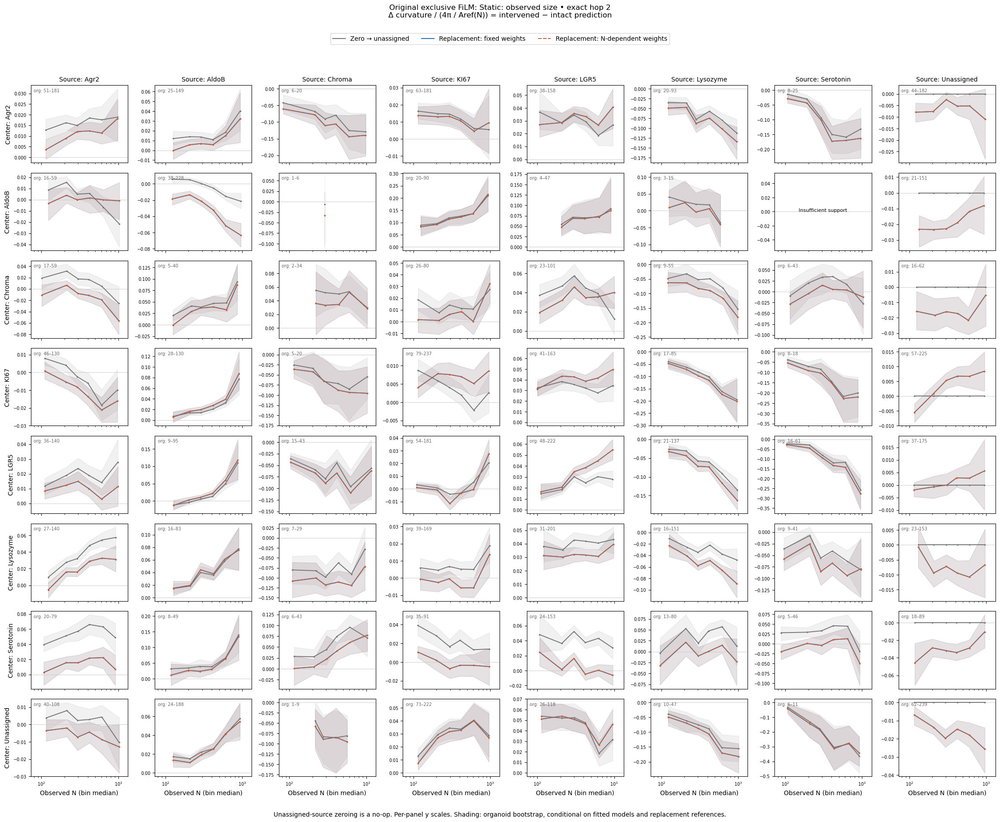

In [5]:
for hop in HOPS:
    fig = plot_pair_grid(result, analysis='observed', hop=hop,
                         metric=PLOT_METRIC, min_organoids=MIN_PLOT_ORGANOIDS)
    fig.savefig(OUTPUT_DIR / f'figures/02_static_hop{hop}_{PLOT_METRIC}.png', dpi=160, bbox_inches='tight')
    plt.show()

## Size sweeps on fixed neighborhoods

Only the supplied size changes in the FiLM and head; the graph and all intact fate vectors stay fixed. Fixed-reference curves isolate the model's response to size for an unchanged comparison distribution. N-dependent curves also include changes in the reference mixture. These are conditional network probes, not tracked developmental trajectories or physical fate conversions.

The normalized curves use `A_ref(supplied N)`. Change `PLOT_METRIC` to `delta_mu` to inspect curvature-unit contrasts without the geometric factor, or `delta_z` for the model's transformed output. Saved contrasts support these views without more inference.

N-dependent reference weights are local empirical estimates. Nearest-neighbor membership and support thresholds can produce changes in those weights; inspect the reference-mixture plot before attributing such bends to the neural network. `fixed_mass_supported_at_N` records how much of the frozen mixture has identity-level support in the N-dependent donor set at each supplied N.

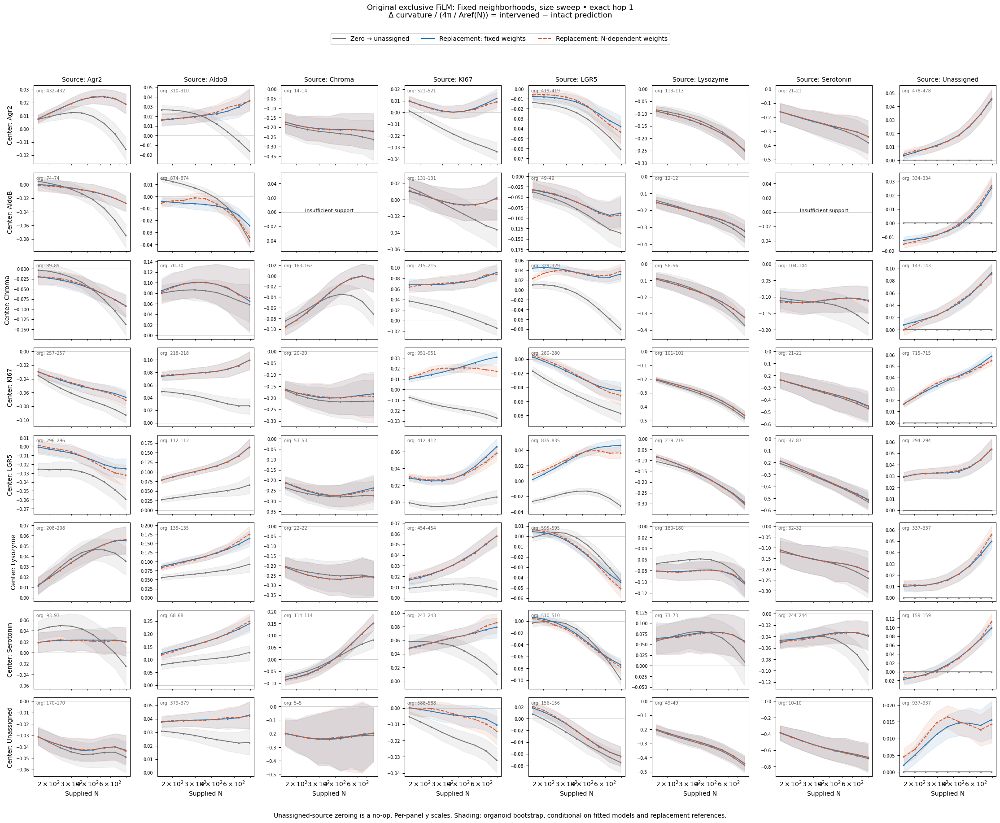

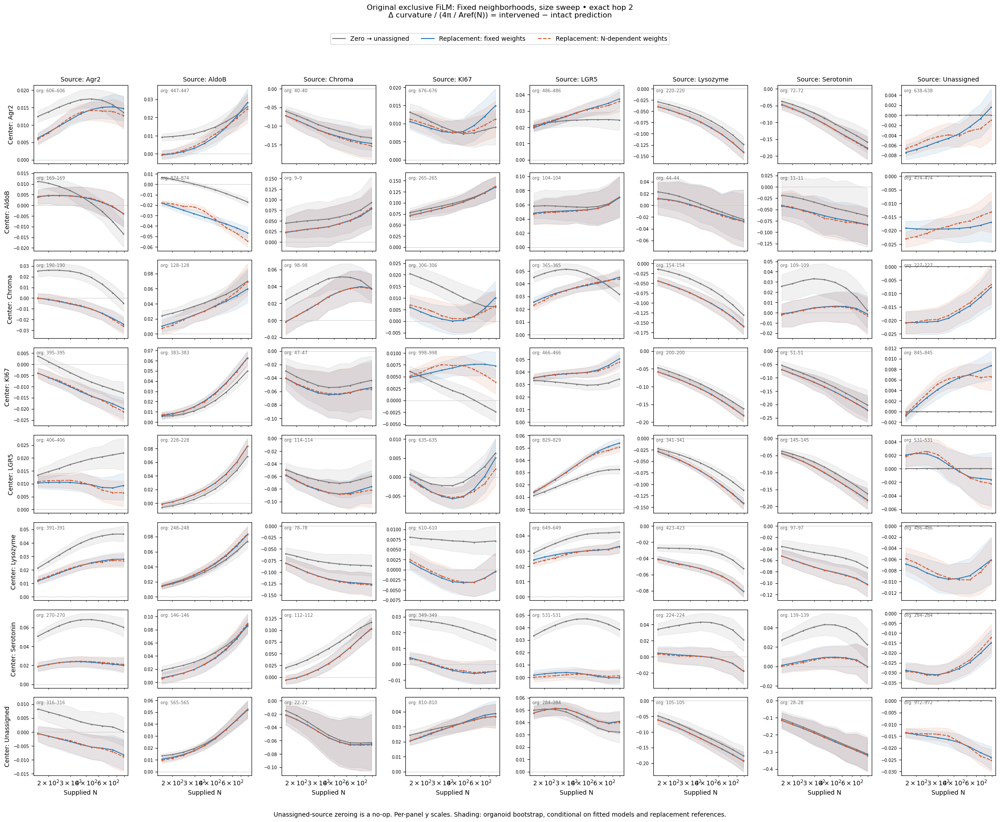

In [6]:
for hop in HOPS:
    fig = plot_pair_grid(result, analysis='sweep', hop=hop,
                         metric=PLOT_METRIC, min_organoids=MIN_PLOT_ORGANOIDS)
    fig.savefig(OUTPUT_DIR / f'figures/03_sweep_hop{hop}_{PLOT_METRIC}.png', dpi=160, bbox_inches='tight')
    plt.show()

## Checks and optional reference inspection

The following checks verify that static reference schemes coincide and that zeroing unassigned sources does nothing. The optional reference plot explains which replacements contribute to a selected curve. Every replacement contrast and its weights are retained in `result['cases']`; weights are `p_fixed_j` / `p_dependent_j`, and curvature contrasts are `delta_identity_j`, with `j` ordered as in `result['config']['markers']`.

A full vector replacement is always applied: the old identity is removed, then exactly one alternative marker is set (or all zeros for Unassigned). Unsupported alternatives can have an enumerated network prediction but receive no replacement probability. Do not interpret those individual predictions as supported biological alternatives.

In [7]:
all_cases = result['cases']
static = all_cases[(all_cases.analysis == 'observed') & all_cases.fixed_supported]
np.testing.assert_allclose(static.replacement_fixed_delta_mu,
                           static.replacement_size_dependent_delta_mu)
unassigned = all_cases[all_cases.source_marker_name == 'Unassigned']
np.testing.assert_allclose(unassigned.zero_delta_mu, 0, atol=1e-10)
print('Static-mixture equality and unassigned no-op checks passed.')

# Choose identities after inspecting the all-pair figures; no pair is privileged.
REFERENCE_CENTER = None  # e.g. 'AldoB'
REFERENCE_SOURCE = None  # e.g. 'Unassigned'
REFERENCE_HOP = 1
if REFERENCE_CENTER is not None and REFERENCE_SOURCE is not None:
    fig = plot_reference_weights(result, center=REFERENCE_CENTER,
                                  source=REFERENCE_SOURCE, hop=REFERENCE_HOP)
    plt.show()

display(result['summary'].head(12))

Static-mixture equality and unassigned no-op checks passed.


,analysis,center_marker,source_marker_name,hop,coordinate,mean,ci_low,ci_high,n_organoids,n_rows,n,method,metric
0,observed,Agr2,Agr2,1,0.0,0.000714,-0.000267,0.001596,38,165,115.0,zero,delta_mu
1,observed,Agr2,Agr2,1,1.0,0.001013,0.000513,0.001522,107,477,213.0,zero,delta_mu
2,observed,Agr2,Agr2,1,2.0,0.000599,0.000166,0.001109,118,537,305.0,zero,delta_mu
3,observed,Agr2,Agr2,1,3.0,0.000520,0.000123,0.000917,135,543,409.0,zero,delta_mu
4,observed,Agr2,Agr2,1,4.0,0.000045,-0.000428,0.000542,138,567,606.0,zero,delta_mu
5,observed,Agr2,Agr2,1,5.0,-0.001409,-0.002233,-0.000547,65,255,931.0,zero,delta_mu
6,observed,Agr2,Agr2,2,0.0,0.001227,0.000800,0.001756,51,246,113.5,zero,delta_mu
7,observed,Agr2,Agr2,2,1.0,0.001104,0.000871,0.001369,138,675,209.0,zero,delta_mu
8,observed,Agr2,Agr2,2,2.0,0.000845,0.000651,0.001044,162,762,292.0,zero,delta_mu
9,observed,Agr2,Agr2,2,3.0,0.000873,0.000639,0.001087,181,825,422.0,zero,delta_mu


## Learned missing-fate ablation

Train and benchmark the models in **exclusive_fate_masking.ipynb** first. This extension compares all four interventions **within one masking-trained model**: zeroing, fixed-weight replacement, N-dependent replacement, and hiding fate with the trained flag. Recomputing the replacement contrasts on the new checkpoint avoids confusing an intervention change with a model change. Earlier figures retain the historical exclusive model and are labelled accordingly.

The exact old source/center cases and replacement weights are reused; nothing is resampled or rematched. The common support restriction and N-stable cohort are identical to the three-way comparison. The center remains observed and its prediction is compared with that same checkpoint's intact prediction. Zeroing unassigned is a no-op; hiding a known-unassigned identity generally is not.

This cell performs inference only. The default 2% masking rate is preselected, not optimized against the validation results.

In [ ]:
from src.analysis.masking_ablation import run_masking_ablation, load_masking_comparison

MASKING_RUN=ROOT/'results_experiments/fate_masking/exclusive_film_v1'
MASKING_RATE=.05
MASKING_OUTPUT_DIR=OUTPUT_DIR/f'masking_{MASKING_RATE:g}'
RUN_MASKING_INFERENCE=True

if not (MASKING_RUN/'training_complete.json').exists():
    raise FileNotFoundError('Train exclusive_fate_masking.ipynb first, or set MASKING_RUN to a completed masking run.')
if RUN_MASKING_INFERENCE:
    run_masking_ablation(ROOT,OUTPUT_DIR,MASKING_RUN,MASKING_OUTPUT_DIR,
        rate=MASKING_RATE,batch_size=BATCH_SIZE,device=DEVICE)
mask_result=load_masking_comparison(MASKING_OUTPUT_DIR,bootstrap_samples=BOOTSTRAP_SAMPLES)
print(mask_result['model_label'])

Loaded 1100 graphs; skipped 0.
=== Target outlier interpolation report ===
Quantiles: [0.005, 0.995]
target 0: range=[-0.201986, 0.236541] | outliers=4778 | replaced=4778 | fallback=42 | rejected_interp=42
Masking ablation fold=0 seed=42, observed
Masking ablation fold=0 seed=42, N165
Masking ablation fold=0 seed=42, N201
Masking ablation fold=0 seed=42, N244
Masking ablation fold=0 seed=42, N297
Masking ablation fold=0 seed=42, N361
Masking ablation fold=0 seed=42, N439
Masking ablation fold=0 seed=42, N535
Masking ablation fold=0 seed=42, N650
Masking ablation fold=0 seed=42, N791
Masking ablation fold=0 seed=43, observed
Masking ablation fold=0 seed=43, N165
Masking ablation fold=0 seed=43, N201
Masking ablation fold=0 seed=43, N244
Masking ablation fold=0 seed=43, N297
Masking ablation fold=0 seed=43, N361
Masking ablation fold=0 seed=43, N439
Masking ablation fold=0 seed=43, N535
Masking ablation fold=0 seed=43, N650
Masking ablation fold=0 seed=43, N791
Masking ablation fold=0 se

### Static and swept four-way comparisons

All curves below come from the selected masking-trained checkpoint. Positive means higher predicted curvature after the intervention. Geometric normalization is identical to the earlier analysis. At observed N the two replacement mixtures still coincide; the unknown-fate reference can differ because it learns to predict from remaining information and does not exclude the source's original identity from what is plausible.

Historical-versus-new differences can reflect training augmentation, the new input channel, and the new checkpoint-selection protocol. Use the matched 0% control in the training notebook to assess augmentation effects.

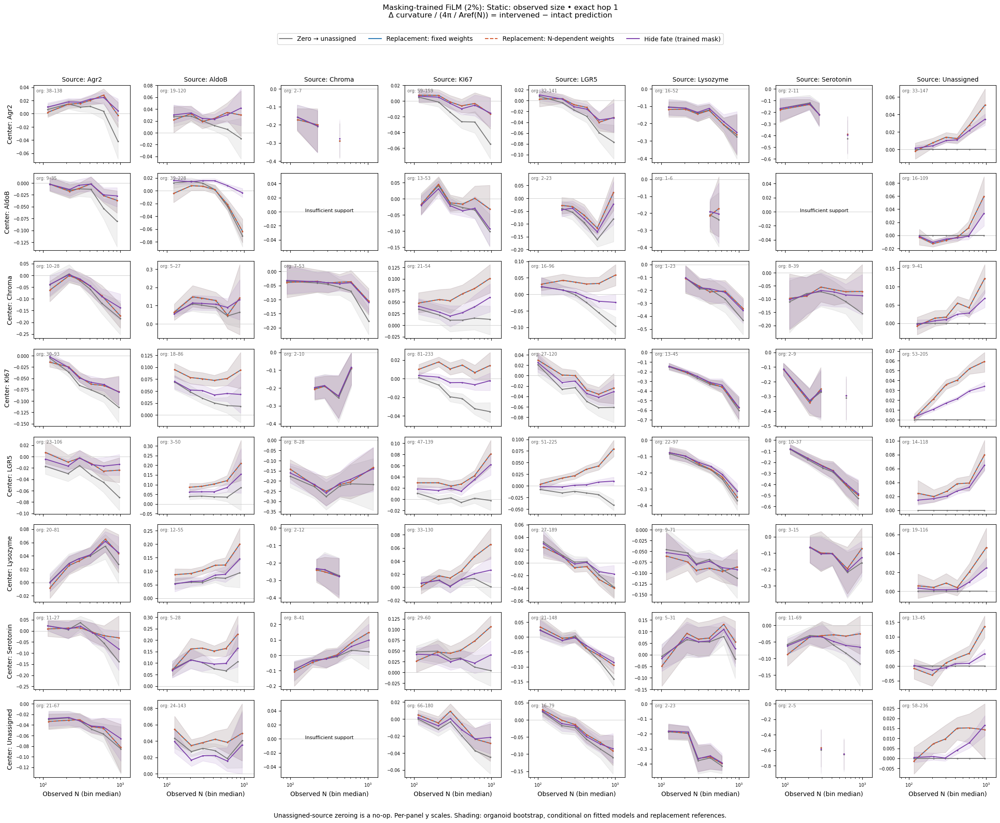

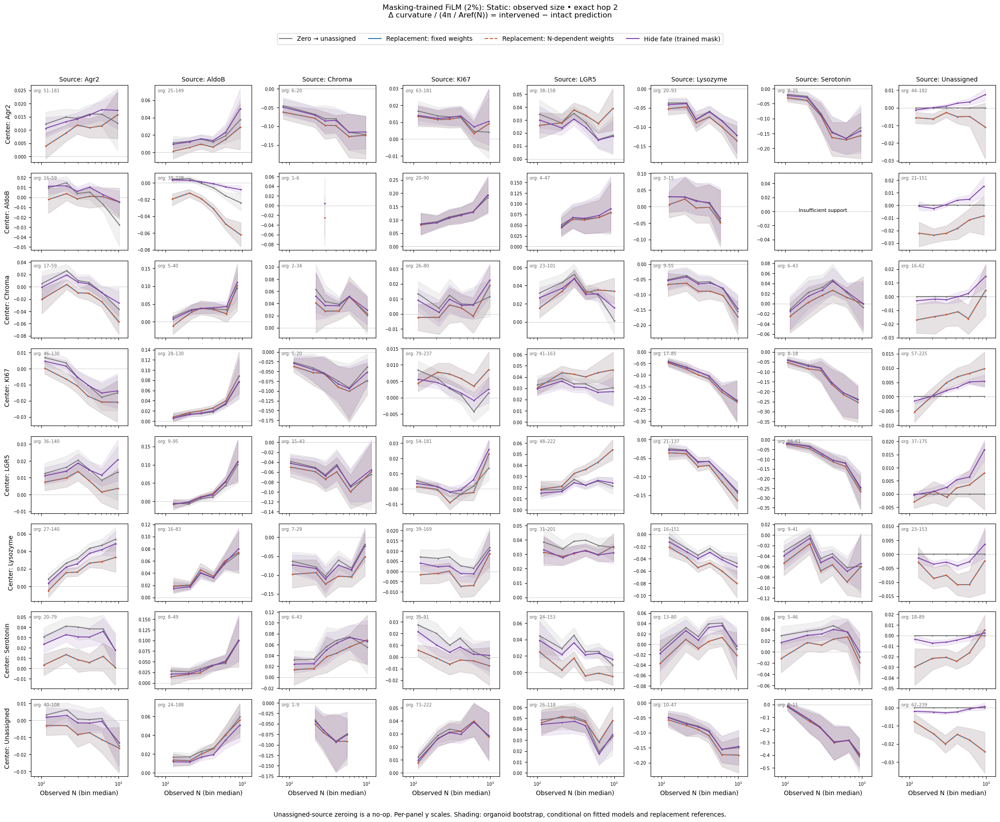

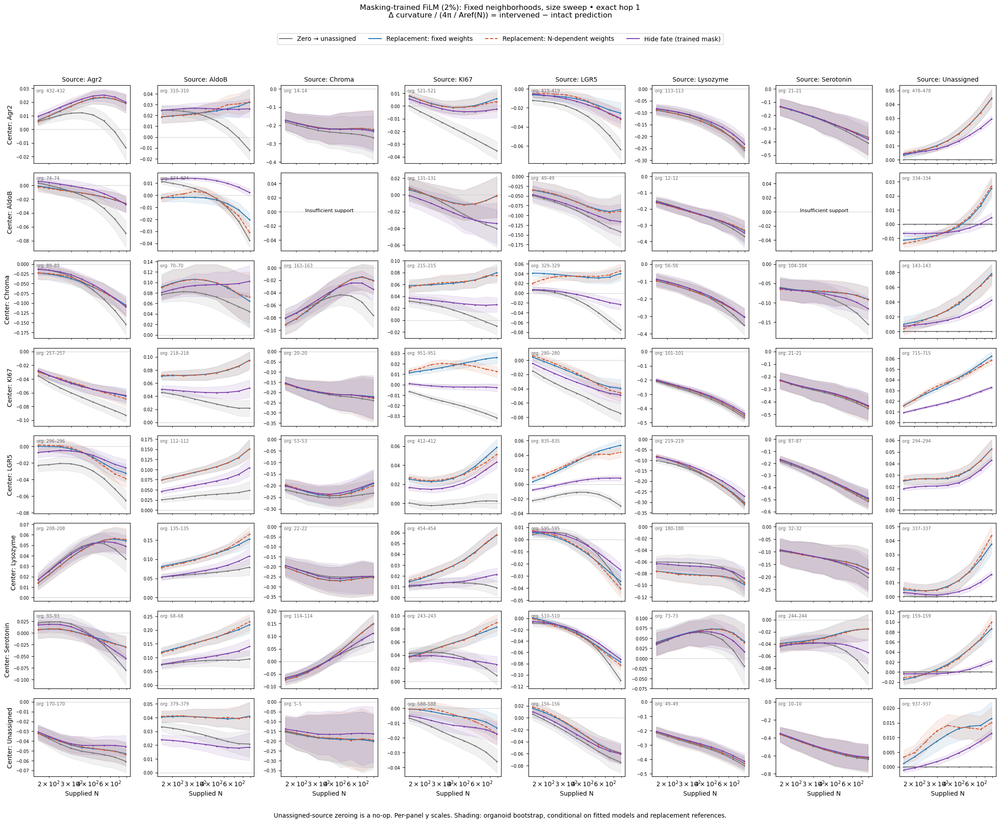

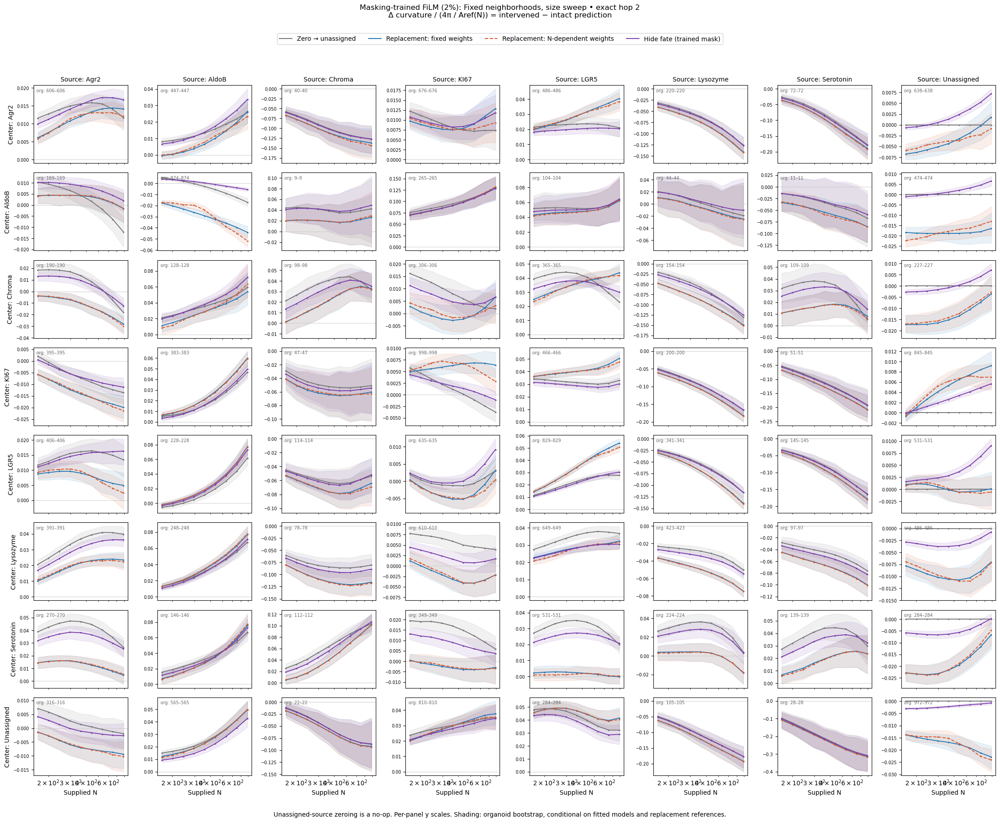

,analysis,center_marker,source_marker_name,hop,coordinate,metric,mean_historical,n_organoids_historical,mean_mask_trained,n_organoids_mask_trained,mean_change
0,observed,Agr2,Agr2,1,0.0,delta_mu,0.000714,38,0.000564,38,-0.000150
1,observed,Agr2,Agr2,1,1.0,delta_mu,0.001013,107,0.000988,107,-0.000025
2,observed,Agr2,Agr2,1,2.0,delta_mu,0.000599,118,0.000570,118,-0.000029
3,observed,Agr2,Agr2,1,3.0,delta_mu,0.000520,135,0.000522,135,0.000002
4,observed,Agr2,Agr2,1,4.0,delta_mu,0.000045,138,0.000137,138,0.000092
5,observed,Agr2,Agr2,1,5.0,delta_mu,-0.001409,65,-0.001273,65,0.000136
6,observed,Agr2,Agr2,2,0.0,delta_mu,0.001227,51,0.001180,51,-0.000047
7,observed,Agr2,Agr2,2,1.0,delta_mu,0.001104,138,0.001016,138,-0.000088
8,observed,Agr2,Agr2,2,2.0,delta_mu,0.000845,162,0.000811,162,-0.000033
9,observed,Agr2,Agr2,2,3.0,delta_mu,0.000873,181,0.000758,181,-0.000115


In [9]:
for analysis in ('observed','sweep'):
    for hop in HOPS:
        fig=plot_pair_grid(mask_result,analysis=analysis,hop=hop,
            metric=PLOT_METRIC,min_organoids=MIN_PLOT_ORGANOIDS)
        fig.savefig(MASKING_OUTPUT_DIR/f'figures/{analysis}_hop{hop}_{PLOT_METRIC}.png',dpi=160,bbox_inches='tight')
        plt.show()

# Explicit same-case comparison of the old and new checkpoint's zeroing effects.
old_zero=result['summary'].query("method == 'zero'")
new_zero=mask_result['summary'].query("method == 'zero'")
keys=['analysis','center_marker','source_marker_name','hop','coordinate','metric']
retraining_check=old_zero[keys+['mean','n_organoids']].merge(
    new_zero[keys+['mean','n_organoids']],on=keys,suffixes=('_historical','_mask_trained'),validate='one_to_one')
retraining_check['mean_change']=retraining_check['mean_mask_trained']-retraining_check['mean_historical']
retraining_check.to_csv(MASKING_OUTPUT_DIR/'historical_vs_mask_trained_zero.csv',index=False)
display(retraining_check.head(16))